# 空间变异分析（Meuse）：按理论教学顺序的 Notebook

本 Notebook 与 [`spatial_variability_theory.md`](spatial_variability_theory.md) **同一套叙事顺序**：**动机 → 随机函数与数据 → 平稳性直觉 → 协方差/半变异定义（含示意曲线）→ 经验估计 → 参数化模型与拟合 → 读参数与克里金衔接**。每一大节前用一小段文字 **压缩复述理论要点**（详细证明与讨论仍以 Markdown 为准），紧接着用 **图或代码** 落地。

**数据**：荷兰 Meuse 河漫滩土壤样点（[`data/README.md`](../../data/README.md)）。**区域化变量**：`log(zinc)`。**坐标**：RD / EPSG:28992（米），各向同性欧氏距离。

| Notebook 顺序 | 理论文档（展开阅读） |
|----------------|----------------------|
| §1 动机 | [spatial_variability_theory.md §1](spatial_variability_theory.md#1-问题设定为何需要空间变异) |
| §2 数据与变换 | [spatial_variability_theory.md §2](spatial_variability_theory.md#2-区域化变量与随机函数) |
| §3 探索性分布与趋势 | [spatial_variability_theory.md §3](spatial_variability_theory.md#3-平稳性从能估计什么出发) |
| §4 $\gamma(h)$ 长什么样 | [spatial_variability_theory.md §4](spatial_variability_theory.md#4-协方差函数与变异函数)、[§7 读图](spatial_variability_theory.md#7-块金基台与变程读图与尺度换算) |
| §5 经验半变异 | [spatial_variability_theory.md §5](spatial_variability_theory.md#5-经验半变异与-matheron-估计) |
| §6 模型拟合 | [spatial_variability_theory.md §6](spatial_variability_theory.md#6-常见各向同性变异函数模型) |
| §7 参数与克里金 | [spatial_variability_theory.md §7](spatial_variability_theory.md#7-块金基台与变程读图与尺度换算)、[§8](spatial_variability_theory.md#8-与克里金的关系) |

图件写入 [`outputs/`](../../outputs/)。自上而下 **Run All** 即可复现。

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager

import geopandas as gpd
import gstools as gs

plt.style.use("seaborn-v0_8-whitegrid")


def configure_matplotlib_chinese() -> None:
    candidates = [
        "PingFang SC",
        "PingFang HK",
        "Hiragino Sans GB",
        "Songti SC",
        "STHeiti",
        "Heiti TC",
        "Arial Unicode MS",
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
    ]
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [name, "DejaVu Sans", "Arial", "Helvetica"]
            mpl.rcParams["axes.unicode_minus"] = False
            return
    mpl.rcParams["font.sans-serif"] = [*candidates, *mpl.rcParams["font.sans-serif"]]
    mpl.rcParams["axes.unicode_minus"] = False


configure_matplotlib_chinese()


def repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if (p / "requirements.txt").is_file() and (p / "data").is_dir():
            return p
    return cwd


ROOT = repo_root()
DATA = ROOT / "data" / "processed" / "meuse.csv"
OUT = ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

## §1 动机：空间上的观测通常不是 i.i.d.

若把每个样点当作彼此独立的重复试验，就丢掉了 **「距离越近越相似」** 的结构。空间变异分析要做的，是用 $\gamma(h)$ 或 $C(h)$ 描述 **相似性如何随滞后距离 $h$ 衰减**，为克里金等线性预测提供输入。

详见 [spatial_variability_theory.md §1](spatial_variability_theory.md#1-问题设定为何需要空间变异)。下面进入 **随机函数的一次实现**（本数据集）。

## §2 区域化变量、对数变换与数据表

理论文档 [spatial_variability_theory.md §2](spatial_variability_theory.md#2-区域化变量与随机函数) 把 $Z(\mathbf{x})$ 建模为随机函数的一次实现。土壤重金属常 **右偏**：对 `zinc` 取自然对数得到 `log_zinc`，使分布更接近对称、**二阶描述更稳定**（与常见 `gstat` 教学一致）。

下一格：**直方图（原始 vs 对数）** + `head()`。

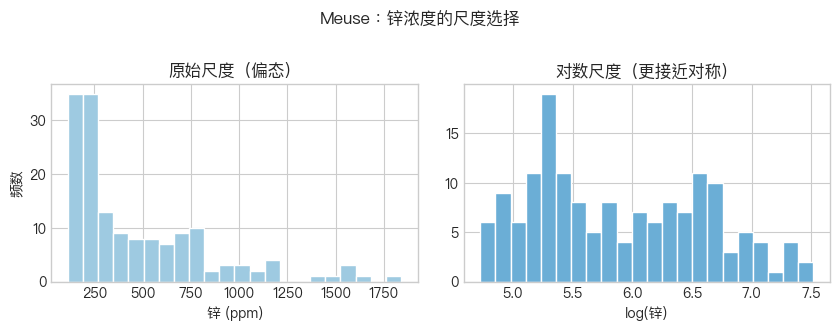

,x,y,cadmium,copper,lead,zinc,elev,dist,om,ffreq,soil,lime,landuse,dist.m,log_zinc,geometry
0,181072,333611,11.7,85,299,1022,7.909,0.001358,13.6,1,1,1,Ah,50,6.929517,POINT (181072 333611)
1,181025,333558,8.6,81,277,1141,6.983,0.012224,14.0,1,1,1,Ah,30,7.039660,POINT (181025 333558)
2,181165,333537,6.5,68,199,640,7.800,0.103029,13.0,1,1,1,Ah,150,6.461468,POINT (181165 333537)
3,181298,333484,2.6,81,116,257,7.655,0.190094,8.0,1,2,0,Ga,270,5.549076,POINT (181298 333484)
4,181307,333330,2.8,48,117,269,7.480,0.277090,8.7,1,2,0,Ah,380,5.594711,POINT (181307 333330)


In [2]:
df = pd.read_csv(DATA)
df["log_zinc"] = np.log(df["zinc"])
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["x"], df["y"]),
    crs="EPSG:28992",
)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2))
axes[0].hist(df["zinc"], bins=22, color="#9ecae1", edgecolor="white")
axes[0].set_xlabel("锌 (ppm)")
axes[0].set_ylabel("频数")
axes[0].set_title("原始尺度（偏态）")
axes[1].hist(df["log_zinc"], bins=22, color="#6baed6", edgecolor="white")
axes[1].set_xlabel("log(锌)")
axes[1].set_title("对数尺度（更接近对称）")
fig.suptitle("Meuse：锌浓度的尺度选择", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "meuse_zinc_log_hist.png", dpi=150)
plt.show()

gdf.head()

## §3 平稳性直觉：先「看图」再估计 $\gamma$

估计 $\hat{\gamma}(h)$ 时，默认 **均值大致稳定**、结构只随 **滞后** 变。若存在强烈 **空间趋势**（整体沿某方向漂移）或明显分区，应先去趋势或分区建模，否则趋势会被误吸进短程相关。

见 [spatial_variability_theory.md §3](spatial_variability_theory.md#3-平稳性从能估计什么出发)。下一格：样点专题图（颜色 = `log_zinc`），用于肉眼检查。

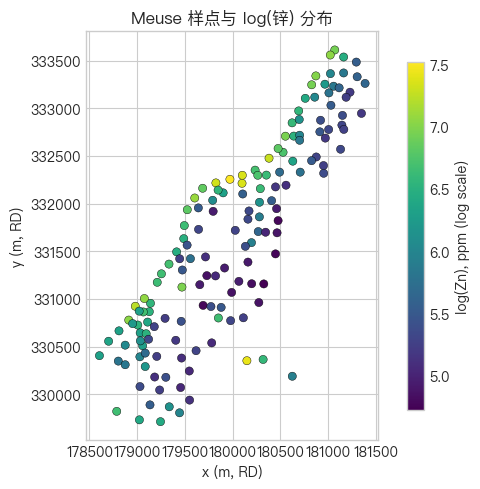

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    gdf["x"],
    gdf["y"],
    c=gdf["log_zinc"],
    cmap="viridis",
    s=35,
    edgecolor="k",
    linewidths=0.3,
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x (m, RD)")
ax.set_ylabel("y (m, RD)")
cb = plt.colorbar(sc, ax=ax, shrink=0.85)
cb.set_label("log(Zn), ppm (log scale)")
ax.set_title("Meuse 样点与 log(锌) 分布")
fig.tight_layout()
fig.savefig(OUT / "meuse_logzn_points.png", dpi=150)
plt.show()

## §4 协方差与半变异：定义 + 「理想曲线」长什么样

二阶平稳下 $\gamma(\mathbf{h})=C(\mathbf{0})-C(\mathbf{h})$：**$h$ 增大，协方差常减小，半变异上升**。下一格绘制 **教学用** 球状型 $\gamma(h)$（块金 $C_0$、部分基台 $C_1$、变程 $a$），**数值与后文 Meuse 拟合无关**，只为把 [spatial_variability_theory.md §4](spatial_variability_theory.md#4-协方差函数与变异函数)、[§7 读图](spatial_variability_theory.md#7-块金基台与变程读图与尺度换算) 的术语钉在一张图上。

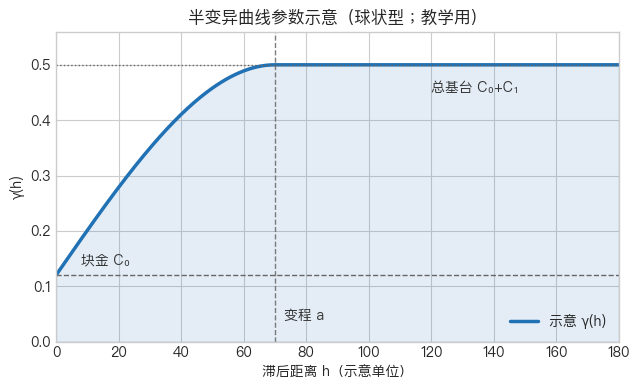

In [4]:
# 教学示意：球状型 γ(h) 的块金、总基台、变程 a（非本数据拟合）


def spherical_gamma(h, nugget, partial_sill, rng):
    h = np.asarray(h, dtype=float)
    C1 = partial_sill
    a = rng
    out = np.empty_like(h)
    m = h <= a
    out[m] = nugget + C1 * (1.5 * h[m] / a - 0.5 * (h[m] / a) ** 3)
    out[~m] = nugget + C1
    return out


h = np.linspace(0, 180, 250)
C0, C1, a = 0.12, 0.38, 70.0
g = spherical_gamma(h, C0, C1, a)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(h, g, color="#2171b5", lw=2.5, label="示意 γ(h)")
ax.axhline(C0, color="#666", ls="--", lw=1)
ax.axhline(C0 + C1, color="#666", ls=":", lw=1)
ax.axvline(a, color="#666", ls="--", lw=1, alpha=0.85)
ax.fill_between(h, 0, g, alpha=0.12, color="#2171b5")
ax.set_xlim(0, 180)
ax.set_ylim(0, C0 + C1 + 0.06)
ax.set_xlabel("滞后距离 h（示意单位）")
ax.set_ylabel("γ(h)")
ax.set_title("半变异曲线参数示意（球状型；教学用）")
ax.annotate("块金 C₀", xy=(8, C0 + 0.02), fontsize=10, color="#333")
ax.annotate("总基台 C₀+C₁", xy=(120, C0 + C1 - 0.05), fontsize=10, color="#333")
ax.annotate("变程 a", xy=(a + 3, 0.04), fontsize=10, color="#333")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUT / "semivariogram_concept.png", dpi=150)
plt.show()

## §5 经验半变异：Matheron 估计与分箱

在 **各向同性** 假设下，将点对距离分箱，对每箱用 Matheron 公式计算 $\hat{\gamma}(h_k)$（定义见 [spatial_variability_theory.md §5](spatial_variability_theory.md#5-经验半变异与-matheron-估计)）。`max_lag` 与 `width` 控制偏差–方差权衡；打印 **counts** 检查空箱。

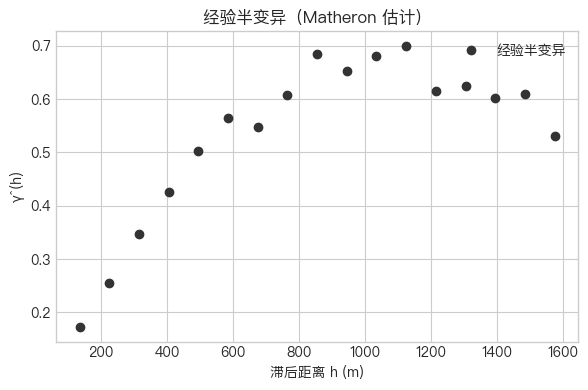

[(np.int64(135), np.float64(0.1719), np.int64(212)),
 (np.int64(225), np.float64(0.2555), np.int64(320)),
 (np.int64(315), np.float64(0.3469), np.int64(371)),
 (np.int64(405), np.float64(0.4263), np.int64(422)),
 (np.int64(495), np.float64(0.5033), np.int64(459)),
 (np.int64(585), np.float64(0.565), np.int64(455)),
 (np.int64(675), np.float64(0.5479), np.int64(466)),
 (np.int64(765), np.float64(0.6077), np.int64(503))]

In [5]:
pos = np.array([gdf["x"].to_numpy(), gdf["y"].to_numpy()])
field = gdf["log_zinc"].to_numpy()

max_lag = 1600.0
width = 90.0
bin_edges = np.arange(width, max_lag + width, width)

bin_center, emp_gamma, counts = gs.vario_estimate(
    pos,
    field,
    bin_edges,
    estimator="matheron",
    mesh_type="unstructured",
    return_counts=True,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bin_center, emp_gamma, "o", color="0.2", label="经验半变异")
ax.set_xlabel("滞后距离 h (m)")
ax.set_ylabel("γ̂(h)")
ax.set_title("经验半变异（Matheron 估计）")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "empirical_variogram.png", dpi=150)
plt.show()

list(zip(np.round(bin_center).astype(int), np.round(emp_gamma, 4), counts))[:8]

## §6 参数化模型与拟合：球状 / 指数 / 高斯

在 [spatial_variability_theory.md §6](spatial_variability_theory.md#6-常见各向同性变异函数模型) 所述的合法模型族中选型，用 `gstools` 对 $(C_0, C_1, \text{len\_scale})$ 搜索，使模型在经验点上的误差（本例 **RMS**）尽量小。下一格打印各模型拟合参数；再下一格画 **经验点 + 最优模型实线 + 其余虚线**。

In [6]:
candidates = {
    "Spherical": gs.Spherical(dim=2),
    "Exponential": gs.Exponential(dim=2),
    "Gaussian": gs.Gaussian(dim=2),
}

fits = {}
for name, model in candidates.items():
    m = model
    m.fit_variogram(bin_center, emp_gamma, nugget=True)
    fits[name] = m
    print(
        f"{name:12s}  nugget={m.nugget:.4f}  partial_sill={m.var:.4f}  len_scale={m.len_scale:.1f} m"
    )

Spherical     nugget=0.0368  partial_sill=0.5940  len_scale=870.3 m
Exponential   nugget=0.0000  partial_sill=0.6550  len_scale=353.4 m
Gaussian      nugget=0.1265  partial_sill=0.5038  len_scale=373.6 m


各模型在 γ 上的 RMS: {'Spherical': 0.03805, 'Exponential': 0.05068, 'Gaussian': 0.03871}
按 RMS 选取的模型: Spherical


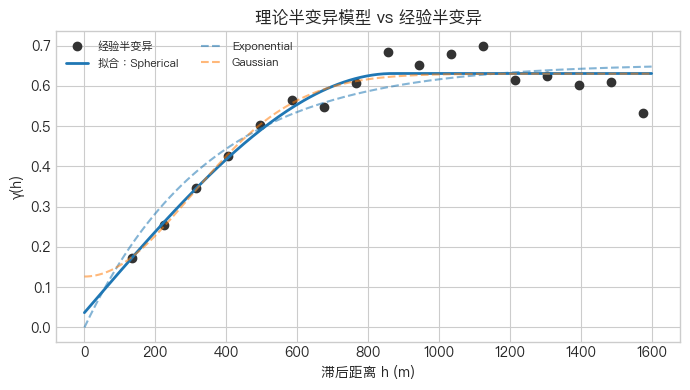

In [7]:
errs = {}
x = np.linspace(0, float(max_lag), 200)
for name, m in fits.items():
    errs[name] = float(np.sqrt(np.mean((m.variogram(bin_center) - emp_gamma) ** 2)))

best = min(errs, key=errs.get)
print("各模型在 γ 上的 RMS:", {k: round(v, 5) for k, v in errs.items()})
print("按 RMS 选取的模型:", best)
best_m = fits[best]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bin_center, emp_gamma, "o", color="0.2", label="经验半变异")
ax.plot(x, best_m.variogram(x), "-", color="C0", linewidth=2, label=f"拟合：{best}")
for name, m in fits.items():
    if name == best:
        continue
    ax.plot(x, m.variogram(x), "--", alpha=0.55, label=f"{name}")
ax.set_xlabel("滞后距离 h (m)")
ax.set_ylabel("γ(h)")
ax.set_title("理论半变异模型 vs 经验半变异")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "fitted_variogram_models.png", dpi=150)
plt.show()

## §7 读出块金、基台、尺度，并接到克里金

- **块金 / 部分基台 / 总基台**：把上一张拟合曲线与 [spatial_variability_theory.md §7](spatial_variability_theory.md#7-块金基台与变程读图与尺度换算) 对照阅读。
- **有效相关距离**：`gstools` 的 `len_scale` 与文献中 $a$ 的换算 **因模型而异**；下一格按常见工程习惯打印近似实用距离。
- **克里金**：[spatial_variability_theory.md §8](spatial_variability_theory.md#8-与克里金的关系) — 线性预测权重完全由协方差结构决定；$\gamma$ 估偏则插值与方差都偏。

各向异性、稳健变异、交叉验证等见 [spatial_variability_theory.md §9](spatial_variability_theory.md#9-本仓库-notebook-未展开的主题延伸阅读)。

In [8]:
nug = float(best_m.nugget)
ps = float(best_m.var)
sill = nug + ps
print(f"块金 (nugget): {nug:.4f}")
print(f"部分基台 (partial sill): {ps:.4f}")
print(f"总基台 (approx. sill): {sill:.4f}")
print(f"相关长度参数 len_scale: {float(best_m.len_scale):.1f} m")

if best == "Spherical":
    eff_range = float(best_m.len_scale)
elif best == "Exponential":
    eff_range = float(3 * best_m.len_scale)
elif best == "Gaussian":
    eff_range = float(np.sqrt(3) * best_m.len_scale)
else:
    eff_range = float("nan")
print(f"经验有效相关距离（常用换算，模型={best}）: ~{eff_range:.0f} m")

块金 (nugget): 0.0368
部分基台 (partial sill): 0.5940
总基台 (approx. sill): 0.6308
相关长度参数 len_scale: 870.3 m
经验有效相关距离（常用换算，模型=Spherical）: ~870 m


### 本 Notebook 产出图件（`outputs/`）

| 文件 | 内容 |
|------|------|
| `meuse_zinc_log_hist.png` | 原始锌 vs log(锌) 直方图（变换动机） |
| `meuse_logzn_points.png` | 样点与 log(锌) 空间分布 |
| `semivariogram_concept.png` | 块金/基台/变程 **示意**（非拟合参数） |
| `empirical_variogram.png` | 经验半变异 |
| `fitted_variogram_models.png` | 模型与经验对比 |

与 [`spatial_variability_theory.md`](spatial_variability_theory.md) **节号对齐** 再读一遍理论，通常比单跑代码或单读公式更省力。